# analisis — inhomogeneidad de |By| en ppm

Carga un HDF5 del **layout v2** (`geometria/<name>/{B, R, meta}` + attrs `perturb_*` a nivel raíz) y calcula la inhomogeneidad de la **magnitud** de la componente **By** (eje dominante del Halbach OSI², con signo negativo en toda la ROI) sobre la grilla.

Para una configuración (sample) $s$ tomamos los `J = Nx · Ny · Nz` puntos de la grilla y reducimos:

$$
\Delta_y^{(s)} \;=\; \frac{\max_J |B_y| - \min_J |B_y|}{\overline{|B_y|}} \qquad\qquad \text{ppm} = 10^6 \cdot \Delta_y^{(s)}
$$

Después se agregan las inhomogeneidades de las `N` configuraciones para reportar mean / std / min / max del dataset.

> Los reportes de campo se hacen en **mT**. La inhomogeneidad y el ppm son adimensionales — invariantes al cambio de unidades — así que el internal storage puede quedar en Tesla sin afectar el resultado. Tomamos `|B_y|` antes de reducir para que el signo de B0 no entre en la cuenta (un Halbach +Y vs −Y debe dar el mismo número).

In [1]:
from pathlib import Path

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print('imports OK')

imports OK


## 1. Configuración

Cambiá `H5_PATH` al dataset que quieras analizar.

In [2]:
# Localiza la raíz del repo (PMDKernel/) probando candidatos: distintos IDEs
# arrancan el notebook desde notebooks/, python/ o el repo raíz.
for candidate in (Path('.'), Path('..'), Path('../..')):
    cand = candidate.resolve()
    if (cand / 'data' / 'datasets').exists():
        REPO_ROOT = cand
        break
else:
    raise RuntimeError("No encontré 'data/datasets/' subiendo desde el cwd")

H5_PATH = REPO_ROOT / 'data' / 'datasets' / 'v1_xyz100_step10_n5000.h5'
assert H5_PATH.exists(), f'No existe: {H5_PATH}'

print(f'REPO_ROOT = {REPO_ROOT}')
print(f'H5_PATH   = {H5_PATH}')
print(f'tamaño    = {H5_PATH.stat().st_size / 1e6:.1f} MB')

REPO_ROOT = C:\Users\Poney\Desktop\Ipre\PMDKernel
H5_PATH   = C:\Users\Poney\Desktop\Ipre\PMDKernel\data\datasets\v1_xyz100_step10_n5000.h5
tamaño    = 567.2 MB


## 2. Carga del dataset

Layout **v2**: `geometria/grid/B (N, J, 3)` mT, `geometria/grid/R (J, 3)` mm, ejes `geometria/grid/meta/{x,y,z}`. Para `n=10, J=62475, 3` en float32 son ~7.5 MB; si tu dataset es mucho más grande y revienta RAM, cambiar a streaming por chunks.

In [3]:
with h5py.File(H5_PATH, 'r') as f:
    B_mT   = f['geometria/grid/B'][:].astype(np.float32)        # (N, J, 3) en mT
    R_grid = f['geometria/grid/R'][:].astype(np.float32)        # (J, 3) mm
    grid_x = f['geometria/grid/meta/x'][:].astype(np.float32)
    grid_y = f['geometria/grid/meta/y'][:].astype(np.float32)
    grid_z = f['geometria/grid/meta/z'][:].astype(np.float32)
    attrs  = dict(f.attrs)

# Escalamos mT -> T antes de cualquier cálculo. El kernel CUDA `B0` devuelve
# Tesla y la pipeline guarda en mT
B = (B_mT * 1e-3).astype(np.float32)   # (N, J, 3) en T
del B_mT

N, J, _ = B.shape
Nx, Ny, Nz = len(grid_x), len(grid_y), len(grid_z)
assert J == Nx * Ny * Nz, f'J={J} != Nx*Ny*Nz={Nx*Ny*Nz}'

B_norm_mT = np.linalg.norm(B, axis=2) * 1e3       # (N, J) en mT — solo para reporte
kind = attrs.get('perturb_kind')
kind = kind.decode() if isinstance(kind, bytes) else kind

print(f'unidades  : B almacenado en Tesla; valores reportados en mT')
print(f'N samples : {N}')
print(f'Grilla    : {Nx} x {Ny} x {Nz} = {J} puntos')
print(f'Rango x   : [{grid_x.min():>5.0f}, {grid_x.max():>5.0f}] mm   step = {grid_x[1]-grid_x[0]:.1f} mm')
print(f'Rango y   : [{grid_y.min():>5.0f}, {grid_y.max():>5.0f}] mm   step = {grid_y[1]-grid_y[0]:.1f} mm')
print(f'Rango z   : [{grid_z.min():>5.0f}, {grid_z.max():>5.0f}] mm   step = {grid_z[1]-grid_z[0]:.1f} mm')
print(f'Rango |B| : [{B_norm_mT.min():>7.3f}, {B_norm_mT.max():>7.3f}] mT')
print(f'Perturb   : kind={kind}, sigma_deg={attrs.get("perturb_sigma_deg")}')

unidades  : B almacenado en Tesla; valores reportados en mT
N samples : 5000
Grilla    : 21 x 21 x 21 = 9261 puntos
Rango x   : [ -100,   100] mm   step = 10.0 mm
Rango y   : [ -100,   100] mm   step = 10.0 mm
Rango z   : [ -100,   100] mm   step = 10.0 mm
Rango |B| : [ 40.972,  60.000] mT
Perturb   : kind=both, sigma_deg=1.0


## 2.bis. Recorte en Z (fine-tuning del dataset)

Define versiones **recortadas** del bloque cargado — `B_crop`, `R_grid_crop`, `grid_z_crop`, `Nz_crop`, `J_crop` — quedándose solo con los `z ∈ [Z_RANGE_MM[0], Z_RANGE_MM[1]]`. Las variables originales (`B`, `R_grid`, `grid_z`, ...) **no se tocan** → quedan disponibles si querés comparar la métrica con y sin recorte.

Es **fine-tuning del dataset ya generado**: el simulador entrega la grilla axial completa (~±250 mm) y acá decidimos sobre qué porción del bore corremos las métricas, sin regenerar el HDF5.

**Forma de filtrar.** La grilla es regular, así que reshape al layout 5D `(N, Nx, Ny, Nz, 3)` y slice sobre el eje Z nombrado:

```python
B_crop = B.reshape(N, Nx, Ny, Nz, 3)[:, :, :, z_mask, :].reshape(N, J_crop, 3)
```

La máscara `z_mask` es 1D de tamaño `Nz` (no `J = Nx·Ny·Nz`) y opera sobre un eje semántico — más rápido y mucho más legible que aplicar un bool-mask al eje flat.

Por qué hace falta: los `|z|` extremos están cerca de los end-caps del Halbach, donde el kernel clampea `|B|` a 60 mT. Esos puntos arruinan la inhomogeneidad sin aportar señal física del *imaging region*.

In [4]:
Z_RANGE_MM = (-250, 250)   # recorte axial del bore útil, en mm

# Filtrado estructural: reshape al layout 5D (N, Nx, Ny, Nz, 3) y slice del
# eje Z nombrado, en vez de un bool-mask sobre los J=Nx*Ny*Nz puntos del eje
# flat. Es la forma idiomática cuando la grilla es regular: la máscara es 1D
# de tamaño Nz (no J) y el slice se aplica sobre un eje semántico.
z_mask = (grid_z >= Z_RANGE_MM[0]) & (grid_z <= Z_RANGE_MM[1])    # (Nz,)

grid_z_crop = grid_z[z_mask]
Nz_crop     = grid_z_crop.size
J_crop      = Nx * Ny * Nz_crop

# Slice estructural del bloque 5D y re-flatten al layout (N, J_crop, 3)
B_crop      = B.reshape(N, Nx, Ny, Nz, 3)[:, :, :, z_mask, :].reshape(N, J_crop, 3)
R_grid_crop = R_grid.reshape(Nx, Ny, Nz, 3)[:, :, z_mask, :].reshape(J_crop, 3)

B_crop_norm_mT = np.linalg.norm(B_crop, axis=2) * 1e3   # (N, J_crop) en mT — para reporte

print(f'recorte z   : [{Z_RANGE_MM[0]:>+5}, {Z_RANGE_MM[1]:>+5}] mm')
print(f'Nz          : {Nz} → {Nz_crop}   (descartados {Nz - Nz_crop} cortes axiales)')
print(f'J           : {J} → {J_crop}   ({100*J_crop/J:.1f}% de la grilla original)')
print(f'Rango z     : [{grid_z_crop.min():>5.0f}, {grid_z_crop.max():>5.0f}] mm   step = {grid_z_crop[1]-grid_z_crop[0]:.1f} mm')
print(f'Rango |B|   : [{B_crop_norm_mT.min():>7.3f}, {B_crop_norm_mT.max():>7.3f}] mT')

recorte z   : [ -250,  +250] mm
Nz          : 21 → 21   (descartados 0 cortes axiales)
J           : 9261 → 9261   (100.0% de la grilla original)
Rango z     : [ -100,   100] mm   step = 10.0 mm
Rango |B|   : [ 40.972,  60.000] mT


## 2.ter. Máscara ROI (región de interés)

La grilla simulada puede tener valores que explotan cerca de los imanes, para esto el simulador clampea a 60 mT, aún así sin filtro la inhomogeneidad incluye puntos irreales y explota a ~10⁶ ppm.

$$
r_{xy} \;=\; \sqrt{x^2 + y^2} \;\leq\; R_\mathrm{ROI},
$$



In [5]:
ROI_RADIUS_MM = 100   # radio del cilindro ROI en el plano XY, en mm

# Trabajamos sobre la grilla recortada (`*_crop`) — la celda 2.bis ya filtró
# los z extremos. Si querés correr esto sobre la grilla completa, cambiá las
# referencias a las variables sin sufijo.
r_xy     = np.linalg.norm(R_grid_crop[:, :2], axis=1)   # (J_crop,) distancia radial al eje Z
mask_roi = r_xy <= ROI_RADIUS_MM
J_roi    = int(mask_roi.sum())

B_roi = B_crop[:, mask_roi, :]                          # (N, J_roi, 3) en T

By_roi        = B_roi[..., 1]                            # (N, J_roi) en T — solo By
B_roi_norm_mT = np.linalg.norm(B_roi, axis=2) * 1e3     # (N, J_roi) en mT — |B| dentro de la ROI

print(f'ROI radius : {ROI_RADIUS_MM:.1f} mm   (cilindro alrededor del eje Z)')
print(f'puntos ROI : {J_roi} de {J_crop}   ({100*J_roi/J_crop:.1f}% de la grilla recortada)')
print(f'|B| en ROI : min = {B_roi_norm_mT.min():>7.3f} mT   max = {B_roi_norm_mT.max():>7.3f} mT')
print(f'|B| crop   : min = {B_crop_norm_mT.min():>7.3f} mT   max = {B_crop_norm_mT.max():>7.3f} mT   (referencia, sin máscara radial)')

ROI radius : 100.0 mm   (cilindro alrededor del eje Z)
puntos ROI : 6657 de 9261   (71.9% de la grilla recortada)
|B| en ROI : min =  49.067 mT   max =  51.749 mT
|B| crop   : min =  40.972 mT   max =  60.000 mT   (referencia, sin máscara radial)


## 2.quater. Visualización interactiva de la grilla y la ROI

Mapa de calor de **By** en cortes XY con controles arriba del plot.

**Navegación**
- **▶ Play / Pause** — anima recorriendo todos los `k_z` automáticamente (intervalo 300 ms; el mismo botón pausa).
- **`k_z`** slider — recorre los `Nz` cortes a lo largo del bore (`z` va de `grid_z.min()` a `grid_z.max()`).
- **`sample`** slider — recorre las `N` configuraciones perturbadas.

**Guardado** (los archivos van al cwd del notebook, `python/notebooks/`)
- **`nombre`** — prefijo base del archivo.
- **`gif fps`** — frames por segundo del GIF.
- **PNG (frame)** — exporta el corte actual como `<nombre>_s<sample>_k<k_z>.png` a 150 dpi.
- **GIF (todo z)** — recorre los `Nz` cortes de la sample actual y arma `<nombre>_s<sample>.gif`. Tarda unos segundos (renderiza los 51 frames y los compone con Pillow).

El colorbar es **adaptativo por slice** (cada corte usa su propio min/max). Debajo del plot, dos líneas reportan los rangos de `By` y `|B|` en el slice y avisan con `← clamp` cuando se tocan los 60 mT.

> Eje X invertido por convención del resonador (`+x` crece derecha → izquierda). Requiere `ipywidgets` (estándar Jupyter) y `Pillow` (viene con `matplotlib`).

In [ ]:
import io
from pathlib import Path as _Path

import ipywidgets as widgets
from IPython.display import display, clear_output
from PIL import Image

# Pre-cómputo sobre la grilla recortada: reshape al layout 5D y máscara 2D
# (XY, invariante en Z). Si querés ver la grilla original sin recortar,
# cambiá las referencias a las variables sin sufijo `_crop`.
B_grid  = B_crop.reshape(N, Nx, Ny, Nz_crop, 3)
Xg, Yg  = np.meshgrid(grid_x, grid_y, indexing='ij')
mask_2d = (Xg**2 + Yg**2) <= ROI_RADIUS_MM**2


def _render_figure(sample_idx, k_z):
    """Crea y devuelve fig + arrays auxiliares. El caller cierra la fig."""
    z_slice    = float(grid_z_crop[k_z])
    B_slice    = B_grid[sample_idx, :, :, k_z, :]               # (Nx, Ny, 3) en T
    By_full_mT = B_slice[..., 1] * 1e3                          # (Nx, Ny) en mT
    By_roi_mT  = np.where(mask_2d, By_full_mT, np.nan)
    Babs_mT    = np.linalg.norm(B_slice, axis=-1) * 1e3         # (Nx, Ny) en mT
    vmin, vmax = float(By_full_mT.min()), float(By_full_mT.max())

    fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), sharex=True, sharey=True)
    for ax, data, subtitle in zip(
        axes,
        [By_full_mT, By_roi_mT],
        ['grilla completa', f'solo ROI (r_xy ≤ {ROI_RADIUS_MM} mm)'],
    ):
        pcm = ax.pcolormesh(Xg, Yg, data, cmap='RdBu_r',
                            vmin=vmin, vmax=vmax, shading='auto')
        ax.add_patch(plt.Circle((0, 0), ROI_RADIUS_MM,
                                fill=False, ec='black', lw=1.5, ls='--'))
        ax.set_aspect('equal')
        ax.set_xlabel('x [mm]')
        ax.set_ylabel('y [mm]')
        ax.set_title(f'By — {subtitle}')
        ax.invert_xaxis()
        fig.colorbar(pcm, ax=ax, label='By [mT]')

    fig.suptitle(f'sample {sample_idx} — slice XY @ z = {z_slice:+.0f} mm  (k_z = {k_z})')
    fig.tight_layout()
    return fig, By_full_mT, Babs_mT


# --- Widgets ---
default_k = int(np.argmin(np.abs(grid_z_crop)))

play_widget   = widgets.Play(value=default_k, min=0, max=Nz_crop-1, step=1,
                             interval=300, description='▶')
k_z_slider    = widgets.IntSlider(value=default_k, min=0, max=Nz_crop-1, description='k_z')
sample_slider = widgets.IntSlider(value=0, min=0, max=N-1, description='sample')
fps_slider    = widgets.IntSlider(value=5, min=1, max=20, description='gif fps')
fname_input   = widgets.Text(value='analisis_by', description='nombre')
save_png_btn  = widgets.Button(description='PNG (frame)',  icon='image',
                               button_style='info')
save_gif_btn  = widgets.Button(description='GIF (todo z)', icon='film',
                               button_style='warning')
status        = widgets.HTML(value='')

widgets.jslink((play_widget, 'value'), (k_z_slider, 'value'))

out_plot = widgets.Output()


def _redraw(*_):
    with out_plot:
        clear_output(wait=True)
        fig, By_full_mT, Babs_mT = _render_figure(sample_slider.value, k_z_slider.value)
        plt.show()
        By_in   = By_full_mT[mask_2d]
        Babs_in = Babs_mT[mask_2d]
        clamp   = '   ← clamp (60 mT)' if Babs_mT.max() >= 60.0 - 1e-3 else ''
        print(f'slice·ROI :  By  ∈ [{By_in.min():>+7.3f}, {By_in.max():>+7.3f}] mT   '
              f'|B| ∈ [{Babs_in.min():>7.3f}, {Babs_in.max():>7.3f}] mT')
        print(f'slice full: |B| max = {Babs_mT.max():>7.3f} mT{clamp}')


def _on_save_png(_btn):
    fig, *_ = _render_figure(sample_slider.value, k_z_slider.value)
    path = _Path(f'{fname_input.value}_s{sample_slider.value}_k{k_z_slider.value:02d}.png').resolve()
    fig.savefig(path, dpi=150, bbox_inches='tight')
    plt.close(fig)
    status.value = f'<b>PNG guardado:</b> <code>{path}</code>'


def _on_save_gif(_btn):
    sample = sample_slider.value
    fps    = fps_slider.value
    path   = _Path(f'{fname_input.value}_s{sample}.gif').resolve()
    save_gif_btn.disabled = True
    try:
        frames = []
        for k in range(Nz_crop):
            status.value = f'rendereando frame {k+1}/{Nz_crop}…'
            fig, *_ = _render_figure(sample, k)
            buf = io.BytesIO()
            fig.savefig(buf, format='png', dpi=80, bbox_inches='tight')
            plt.close(fig)
            buf.seek(0)
            frames.append(Image.open(buf).convert('RGB'))
        frames[0].save(path, save_all=True, append_images=frames[1:],
                       duration=int(1000 / fps), loop=0, optimize=True)
        status.value = f'<b>GIF guardado:</b> <code>{path}</code> ({Nz_crop} frames @ {fps} fps)'
    finally:
        save_gif_btn.disabled = False


k_z_slider.observe(_redraw,    names='value')
sample_slider.observe(_redraw, names='value')
save_png_btn.on_click(_on_save_png)
save_gif_btn.on_click(_on_save_gif)

display(widgets.VBox([
    widgets.HBox([play_widget, k_z_slider, sample_slider]),
    widgets.HBox([fname_input, fps_slider, save_png_btn, save_gif_btn]),
    status,
    out_plot,
]))
_redraw()

## 3. Inhomogeneidad de |By| — una configuración

Tomamos un sample (`SAMPLE_IDX`), pasamos a magnitud `|By|` y reducimos sobre los `J_roi` puntos de la ROI. Reportamos `(max - min) / mean` (adimensional) y su valor en ppm. Trabajar con `|By|` evita el signo artificial: B0 apunta sobre -Y → todos los `By` son negativos, pero la inhomogeneidad mide dispersión relativa de la intensidad y no debe depender de la convención de signo.

In [7]:
SAMPLE_IDX = 0

# Trabajamos con la magnitud |By|: B0 en el OSI² apunta sobre -Y, así que By
# es negativo en toda la ROI. La inhomogeneidad mide dispersión relativa de la
# intensidad del campo, así que el signo no debe entrar en la cuenta.
By_abs = np.abs(By_roi[SAMPLE_IDX])   # (J_roi,) en T — storage en T (display en mT abajo)

By_min  = float(By_abs.min())
By_max  = float(By_abs.max())
By_mean = float(By_abs.mean())

inhomo     = (By_max - By_min) / By_mean  
inhomo_ppm = inhomo * 1e6

print(f'Sample idx     : {SAMPLE_IDX}   (de {N})')
print(f'puntos en ROI  : J_roi = {J_roi}   (radio xy = {ROI_RADIUS_MM:.1f} mm)')
print(f'|By|_min       : {By_min*1e3:>9.4f} mT')
print(f'|By|_max       : {By_max*1e3:>9.4f} mT')
print(f'|By|_mean      : {By_mean*1e3:>9.4f} mT')
print(f'(max-min)/mean : {inhomo:.6e}')
print(f'inhomogeneidad : {inhomo_ppm:.3e} ppm')

Sample idx     : 0   (de 5000)
puntos en ROI  : J_roi = 6657   (radio xy = 100.0 mm)
|By|_min       :   49.7553 mT
|By|_max       :   51.2114 mT
|By|_mean      :   50.6652 mT
(max-min)/mean : 2.873986e-02
inhomogeneidad : 2.874e+04 ppm


## 4. Inhomogeneidad sobre las N configuraciones

Aplicamos el mismo cálculo a todas las samples (vectorizado) y reportamos mean / std / min / max / percentiles del valor en ppm.

In [16]:
By_abs       = np.abs(By_roi)            # (N, J_roi) — magnitudes
By_min_all   = By_abs.min(axis=1)         # (N,)
By_max_all   = By_abs.max(axis=1)
By_mean_all  = By_abs.mean(axis=1)

inhomo_all     = (By_max_all - By_min_all) / By_mean_all
inhomo_ppm_all = inhomo_all * 1e6

print(f'Inhomogeneidad de |By| en ppm — ROI cilíndrica r_xy={ROI_RADIUS_MM:.0f} mm — {N} samples:')
print(f'  mean   : {inhomo_ppm_all.mean():.4e} ppm')
print(f'  std    : {inhomo_ppm_all.std():.4e} ppm')
print(f'  min    : {inhomo_ppm_all.min():.4e} ppm')
print(f'  p05    : {np.percentile(inhomo_ppm_all,  5):.4e} ppm')
print(f'  median : {np.median(inhomo_ppm_all):.4e} ppm')
print(f'  p95    : {np.percentile(inhomo_ppm_all, 95):.4e} ppm')
print(f'  max    : {inhomo_ppm_all.max():.4e} ppm')

Inhomogeneidad de |By| en ppm — ROI cilíndrica r_xy=100 mm — 1 samples:
  mean   : 2.7588e+05 ppm
  std    : 0.0000e+00 ppm
  min    : 2.7588e+05 ppm
  p05    : 2.7588e+05 ppm
  median : 2.7588e+05 ppm
  p95    : 2.7588e+05 ppm
  max    : 2.7588e+05 ppm


## 5. Distribución de la inhomogeneidad sobre samples

ValueError: Too many bins for data range. Cannot create 60 finite-sized bins.

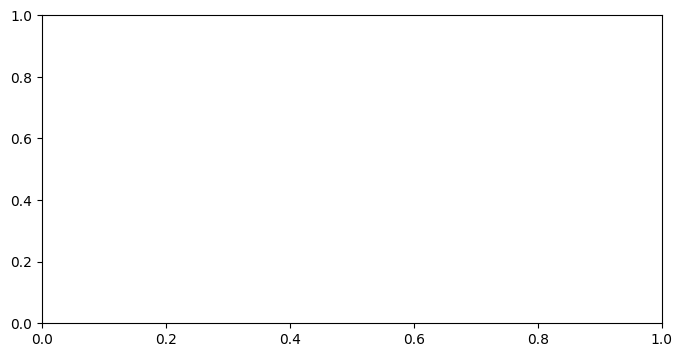

In [17]:
plt.figure(figsize=(8, 4))
plt.hist(inhomo_ppm_all, bins=60, color='steelblue', edgecolor='white')
plt.axvline(inhomo_ppm_all.mean(),    color='crimson', ls='--', lw=1.2,
            label=f'mean   = {inhomo_ppm_all.mean():.3e} ppm')
plt.axvline(np.median(inhomo_ppm_all), color='black',  ls=':',  lw=1.2,
            label=f'median = {np.median(inhomo_ppm_all):.3e} ppm')
plt.xlabel('inhomogeneidad de By [ppm]')
plt.ylabel('# samples')
plt.title(f'Distribución de la inhomogeneidad de By — {N} configuraciones')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()